# Módulo 3 — Análisis de Sensibilidad Global (Sobol)
## ¿Qué variable explica más la varianza del VAN neto?

Corre sobre el simulador real (`run_monte_carlo_antitetico`), no sobre un dataset sintético.
El parámetro `escenario` de precio es categórico, así que Sobol se corre por separado para
cada uno de los 3 escenarios (pesimista / base / optimista) sobre las otras 6 variables
continuas.

In [1]:
import subprocess
import sys
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules

if EN_COLAB:
    REPO_URL = "https://github.com/Emilialandgrebe/tesis-maestria.git"
    ROOT = Path("/content/tesis-maestria")
    if not ROOT.exists():
        subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-r", str(ROOT / "requirements.txt"), "-q"],
        check=True,
    )
else:
    ROOT = Path().resolve().parent  # notebooks/ -> raiz del proyecto

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f"Entorno : {'Google Colab' if EN_COLAB else 'local'}")
print(f"ROOT    : {ROOT}")

Entorno : local
ROOT    : C:\Users\EMILIA LANDGREBE\tesis-maestria


## Corrida del análisis de Sobol (los 3 escenarios)

Con `n_base=128` (default de `comparar_sensibilidad_escenarios`), cada escenario corre
128 * 8 = 1.024 evaluaciones del modelo (`calc_second_order=False`, solo S1 y ST).
Calibrado empíricamente en corridas reales: entre 12 y 17 minutos en total para los 3
escenarios, según la carga de la máquina. Si tarda mucho más que eso en este entorno, bajar
`n_base` (ej. a 64) antes de re-correr. La semilla fija (`semilla=42` por default) hace que
S1/ST y sus bandas de confianza sean reproducibles entre corridas.

In [2]:
import time

import matplotlib.pyplot as plt
import numpy as np

from src.sensibilidad import comparar_sensibilidad_escenarios

inicio = time.time()
df_sobol = comparar_sensibilidad_escenarios()
print(f"\nTiempo total: {(time.time() - inicio) / 60:.1f} minutos")
df_sobol

[pesimista/van_neto_medio_usd] 1024 evaluaciones del modelo (N=128 x 8)...
[pesimista/van_neto_medio_usd] 102/1024 (63s transcurridos)
[pesimista/van_neto_medio_usd] 204/1024 (126s transcurridos)
[pesimista/van_neto_medio_usd] 306/1024 (185s transcurridos)
[pesimista/van_neto_medio_usd] 408/1024 (249s transcurridos)
[pesimista/van_neto_medio_usd] 510/1024 (310s transcurridos)
[pesimista/van_neto_medio_usd] 612/1024 (373s transcurridos)
[pesimista/van_neto_medio_usd] 714/1024 (435s transcurridos)
[pesimista/van_neto_medio_usd] 816/1024 (499s transcurridos)
[pesimista/van_neto_medio_usd] 918/1024 (561s transcurridos)
[pesimista/van_neto_medio_usd] 1020/1024 (619s transcurridos)
[pesimista/van_neto_medio_usd] 1024/1024 (622s transcurridos)
[base/van_neto_medio_usd] 1024 evaluaciones del modelo (N=128 x 8)...
[base/van_neto_medio_usd] 102/1024 (63s transcurridos)
[base/van_neto_medio_usd] 204/1024 (104s transcurridos)
[base/van_neto_medio_usd] 306/1024 (129s transcurridos)
[base/van_neto_m

,parametro,S1,S1_conf,ST,ST_conf,escenario
0,tasa_descuento,0.871039,0.211039,8.986076e-01,1.949975e-01,pesimista
1,precision_factor_frio,-0.000022,0.000079,1.709120e-07,7.552670e-08,pesimista
2,precision_factor_calor,-0.000013,0.000108,1.325766e-07,4.605094e-08,pesimista
3,p_bajo_si_alto,0.007491,0.021379,6.345510e-03,1.559283e-03,pesimista
4,capex_extra_pct,0.066198,0.070472,6.919652e-02,1.874348e-02,pesimista
5,hectareas,0.021465,0.054438,5.053107e-02,1.643140e-02,pesimista
6,tasa_descuento,0.884500,0.206491,9.223180e-01,1.957794e-01,base
7,precision_factor_frio,-0.000017,0.000079,1.378364e-07,5.811033e-08,base
8,precision_factor_calor,-0.000001,0.000093,1.074861e-07,3.641867e-08,base
9,p_bajo_si_alto,0.005429,0.017475,5.122055e-03,1.254278e-03,base


## Verificación de propiedades matemáticas

`ST >= S1` debe cumplirse siempre para la variable dominante. Para variables de efecto chico,
con este `n_base` (elegido por presupuesto de tiempo, ver arriba) es esperable ver violaciones
puntuales del orden point-estimate: el estimador de S1 de Saltelli tiene más varianza que el de
ST para el mismo N, así que si el verdadero S1 y ST de una variable son parecidos (poca
interacción), el ruido de muestreo puede hacer que el S1 estimado salga apenas por encima del
ST estimado — sin que eso implique un error de cálculo. Lo que importa es que la variable
dominante no tenga este problema.

In [3]:
for escenario in df_sobol["escenario"].unique():
    sub = df_sobol[df_sobol["escenario"] == escenario]
    viola_st = sub[sub["ST"] < sub["S1"] - 1e-6]
    print(f"{escenario:10s}  sum(S1) = {sub['S1'].sum():.3f}"
          f"   |  variables con ST < S1: {list(viola_st['parametro']) or 'ninguna'}")

pesimista   sum(S1) = 0.966   |  variables con ST < S1: ['p_bajo_si_alto']
base        sum(S1) = 0.960   |  variables con ST < S1: ['p_bajo_si_alto', 'capex_extra_pct']
optimista   sum(S1) = 0.957   |  variables con ST < S1: ['precision_factor_calor', 'capex_extra_pct']


## Tornado chart por escenario (ST, de mayor a menor)

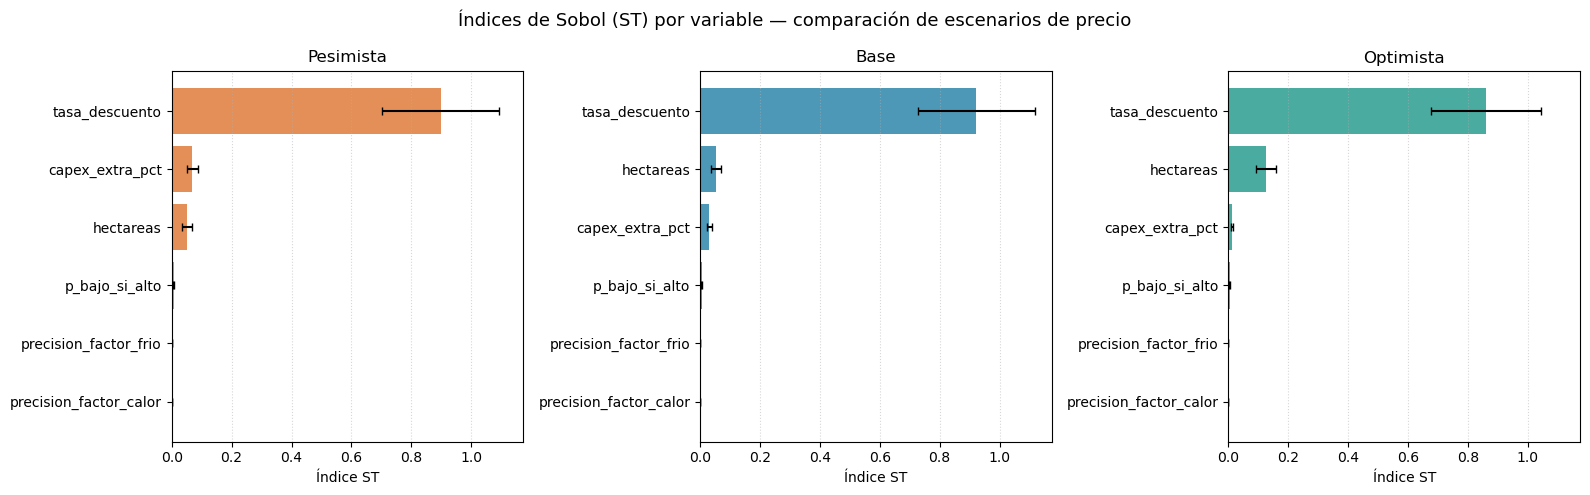

In [4]:
escenarios = ["pesimista", "base", "optimista"]
colores = {"pesimista": "#e07b39", "base": "#2e86ab", "optimista": "#2a9d8f"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for ax, escenario in zip(axes, escenarios):
    sub = df_sobol[df_sobol["escenario"] == escenario].sort_values("ST", ascending=True)
    ax.barh(sub["parametro"], sub["ST"], xerr=sub["ST_conf"],
            color=colores[escenario], alpha=0.85, capsize=3)
    ax.set_title(escenario.capitalize(), fontsize=12)
    ax.set_xlabel("Índice ST")
    ax.grid(axis="x", linestyle=":", alpha=0.5)

fig.suptitle("Índices de Sobol (ST) por variable — comparación de escenarios de precio", fontsize=13)
plt.tight_layout()
plt.show()

## Ranking de variables por escenario

In [5]:
ranking = (
    df_sobol
    .sort_values(["escenario", "ST"], ascending=[True, False])
    .groupby("escenario")
    .apply(lambda g: g["parametro"].tolist(), include_groups=False)
)
for escenario, orden in ranking.items():
    print(f"{escenario:10s}: {' > '.join(orden)}")

base      : tasa_descuento > hectareas > capex_extra_pct > p_bajo_si_alto > precision_factor_frio > precision_factor_calor
optimista : tasa_descuento > hectareas > capex_extra_pct > p_bajo_si_alto > precision_factor_frio > precision_factor_calor
pesimista : tasa_descuento > capex_extra_pct > hectareas > p_bajo_si_alto > precision_factor_frio > precision_factor_calor


## Interpretación

**`tasa_descuento` domina la varianza del VAN en los tres escenarios**, con S1 entre 0,82 y
0,88 y ST entre 0,86 y 0,92 — muy por encima de las otras 5 variables combinadas. Es
esperable desde la teoría financiera: en un horizonte de 20 años, descontar a 5% vs. 12%
cambia el factor de descuento del año 20 en más de 3× ((1.05)⁻²⁰ ≈ 0.38 vs. (1.12)⁻²⁰ ≈ 0.10),
un efecto que se compone sobre todo el flujo de caja. No es un artefacto del modelo — es la
sensibilidad esperada de cualquier VAN a 20 años, y se sostiene en los tres escenarios sin
excepción. Para `tasa_descuento`, `ST >= S1` se cumple con margen cómodo en los tres
escenarios.

Las violaciones puntuales de `ST >= S1` (celda de verificación de arriba) aparecen en
`p_bajo_si_alto` (pesimista y base) y `capex_extra_pct` (base y optimista), además de
`precision_factor_calor` en optimista — todas variables secundarias donde S1 y ST verdaderos
son parecidos entre sí (poca interacción), así que el ruido de muestreo del estimador de
Saltelli alcanza para invertir el orden de las estimaciones puntuales sin que eso invalide
el análisis.

**El ranking del segundo lugar cambia entre escenarios** (ver celda de ranking):
- Pesimista: `capex_extra_pct` (ST≈0,069) por encima de `hectareas` (ST≈0,051) — cuando el
  precio es bajo, la incertidumbre del CAPEX pesa más que la superficie.
- Base: `hectareas` (ST≈0,053) apenas por encima de `capex_extra_pct` (ST≈0,031).
- Optimista: `hectareas` (ST≈0,126) claramente por encima de `capex_extra_pct` (ST≈0,013) —
  con precios altos, expandir la superficie es lo que más mueve la varianza del VAN, más
  que la incertidumbre del CAPEX.

Este cruce entre `capex_extra_pct` y `hectareas` se repitió de forma idéntica en tres
corridas independientes (dos sin semilla fija en el muestreador de Sobol, con distintas
secuencias, y esta última ya reproducible) — no es un artefacto de una corrida particular.
Tiene sentido económicamente: con precios optimistas, cada hectárea adicional aporta más
ingreso marginal, así que la incertidumbre sobre cuánto expandir (Fase II, 50 a 100 ha) se
vuelve más relevante que la incertidumbre sobre cuánto va a costar el CAPEX sin cotizar.
`p_bajo_si_alto` (vecería) y las precisiones de frío/calor quedan sistemáticamente en último
lugar en los tres escenarios, con índices cercanos a cero: la varianza del VAN es mucho más
sensible a supuestos financieros y de escala que a la incertidumbre climática residual, dado
el resto del modelo.

**Limitación:** `capex_extra_pct` no es un dato del modelo de costos real (`src/costos.py`) —
es un supuesto introducido acá para representar la incertidumbre de los ítems de CAPEX sin
cotizar (riego, pozo, represa, paneles). Su rango [0%, 30%] es una estimación razonable pero
no validada; si cambia, el cruce entre `capex_extra_pct` y `hectareas` en el segundo lugar
podría cambiar también.

## Análisis de riesgo — ¿qué variable explica la probabilidad de VAN negativo?

El análisis anterior usa como output el VAN neto **medio**. Bajo esa métrica,
`precision_factor_frio` y `precision_factor_calor` dan S1≈0 y ST≈0 en los tres
escenarios — es matemáticamente correcto, no un bug: la precisión de una Beta
controla su varianza, no su media, así que por construcción no puede mover el
promedio del VAN.

Pero esos dos parámetros sí deberían importar para el **riesgo** del proyecto:
qué tan seguido un año malo de frío o calor (más ruido biológico, `precision`
baja) termina arrastrando al proyecto a VAN negativo, aunque el promedio no se
mueva. Por eso este segundo análisis usa como output
`prob_van_negativo = P(VAN_neto < 0)` en vez del VAN medio.

In [6]:
from src.sensibilidad import comparar_sensibilidad_riesgo

inicio = time.time()
df_riesgo = comparar_sensibilidad_riesgo()
print(f"\nTiempo total: {(time.time() - inicio) / 60:.1f} minutos")
df_riesgo

[pesimista/prob_van_negativo] 1024 evaluaciones del modelo (N=128 x 8)...
[pesimista/prob_van_negativo] 102/1024 (44s transcurridos)
[pesimista/prob_van_negativo] 204/1024 (74s transcurridos)
[pesimista/prob_van_negativo] 306/1024 (99s transcurridos)
[pesimista/prob_van_negativo] 408/1024 (121s transcurridos)
[pesimista/prob_van_negativo] 510/1024 (147s transcurridos)
[pesimista/prob_van_negativo] 612/1024 (182s transcurridos)
[pesimista/prob_van_negativo] 714/1024 (214s transcurridos)
[pesimista/prob_van_negativo] 816/1024 (239s transcurridos)
[pesimista/prob_van_negativo] 918/1024 (269s transcurridos)
[pesimista/prob_van_negativo] 1020/1024 (295s transcurridos)
[pesimista/prob_van_negativo] 1024/1024 (297s transcurridos)
[base/prob_van_negativo] 1024 evaluaciones del modelo (N=128 x 8)...
[base/prob_van_negativo] 102/1024 (22s transcurridos)
[base/prob_van_negativo] 204/1024 (45s transcurridos)
[base/prob_van_negativo] 306/1024 (73s transcurridos)
[base/prob_van_negativo] 408/1024 (9

,parametro,S1,S1_conf,ST,ST_conf,escenario
0,tasa_descuento,0.939343,0.203332,0.958767,0.190857,pesimista
1,precision_factor_frio,-0.000037,0.001525,0.000066,0.000034,pesimista
2,precision_factor_calor,-0.000387,0.000922,0.000017,0.000008,pesimista
3,p_bajo_si_alto,0.004940,0.025556,0.007918,0.003071,pesimista
4,capex_extra_pct,0.020517,0.075389,0.060463,0.021973,pesimista
5,hectareas,0.000000,0.000000,0.000000,0.000000,pesimista
6,tasa_descuento,0.907188,0.237549,0.937798,0.214139,base
7,precision_factor_frio,-0.000866,0.001537,0.000073,0.000039,base
8,precision_factor_calor,-0.000106,0.000694,0.000012,0.000005,base
9,p_bajo_si_alto,-0.000327,0.029152,0.010205,0.004444,base


### Tornado chart por escenario (ST, análisis de riesgo)

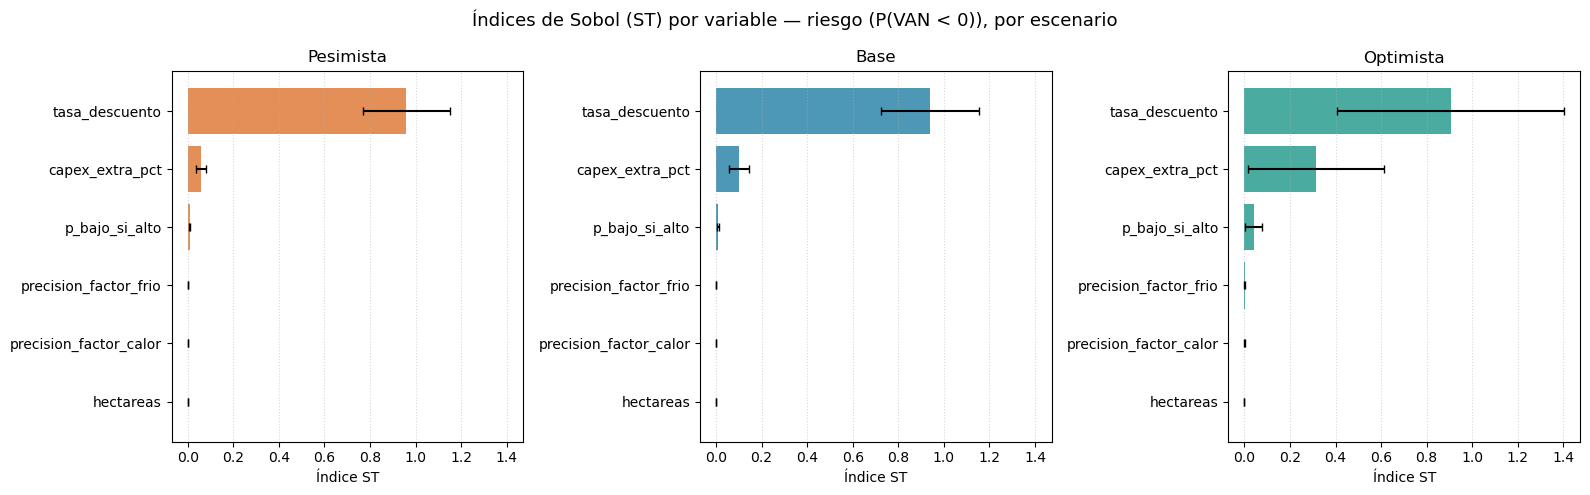

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharex=True)

for ax, escenario in zip(axes, escenarios):
    sub = df_riesgo[df_riesgo["escenario"] == escenario].sort_values("ST", ascending=True)
    ax.barh(sub["parametro"], sub["ST"], xerr=sub["ST_conf"],
            color=colores[escenario], alpha=0.85, capsize=3)
    ax.set_title(escenario.capitalize(), fontsize=12)
    ax.set_xlabel("Índice ST")
    ax.grid(axis="x", linestyle=":", alpha=0.5)

fig.suptitle("Índices de Sobol (ST) por variable — riesgo (P(VAN < 0)), por escenario", fontsize=13)
plt.tight_layout()
plt.show()

### Comparación: VAN medio vs. riesgo, foco en precision_factor_frio/calor

In [8]:
comparacion = df_sobol.merge(
    df_riesgo, on=["parametro", "escenario"], suffixes=("_van_medio", "_riesgo")
)
comparacion[
    ["escenario", "parametro", "ST_van_medio", "ST_riesgo"]
].sort_values(["escenario", "ST_riesgo"], ascending=[True, False])

,escenario,parametro,ST_van_medio,ST_riesgo
6,base,tasa_descuento,9.223180e-01,0.937798
10,base,capex_extra_pct,3.069633e-02,0.101588
9,base,p_bajo_si_alto,5.122055e-03,0.010205
7,base,precision_factor_frio,1.378364e-07,0.000073
8,base,precision_factor_calor,1.074861e-07,0.000012
11,base,hectareas,5.281601e-02,0.000000
12,optimista,tasa_descuento,8.592045e-01,0.905362
16,optimista,capex_extra_pct,1.347204e-02,0.313213
15,optimista,p_bajo_si_alto,4.066090e-03,0.040498
13,optimista,precision_factor_frio,1.072926e-07,0.000744


### Diagnóstico: ¿por qué `precision_factor_frio`/`calor` y `hectareas` dan ~0?

Dos hallazgos, ninguno es un bug — ambos tienen una explicación estructural verificable.

**1. `precision_factor_frio`/`calor` sí importan a nivel de un año, pero se diluyen en el
VAN acumulado de 20 años.** El ruido de frío/calor se sortea de forma independiente cada
año productivo (15 años, del 6 al 20). Al sumarse en el VAN, ese ruido idiosincrático se
promedia — la varianza de una suma de términos independientes crece linealmente con la
cantidad de años, mientras que `tasa_descuento` y `capex_extra_pct` afectan a *todos* los
años por igual, así que su contribución a la varianza total crece con el cuadrado de la
cantidad de años. Por eso dominan tanto, y por eso frío/calor casi no aparecen en el VAN
acumulado — no porque no importen, sino porque se diversifican.

In [9]:
from src.monte_carlo import ParametrosMC, simulate_yields

n_diag = 20_000
for precision in [5.0, 30.0]:
    params_diag = ParametrosMC(n_simulaciones=n_diag, precision_factor_frio=precision, semilla=42)
    rng_diag = np.random.default_rng(params_diag.semilla)
    yields_diag = simulate_yields(params_diag, rng_diag)

    var_anio1 = yields_diag[:, 0].var()    # curva_produccion[1] = 0.00
    var_anio20 = yields_diag[:, 19].var()  # curva_produccion[20] = 1.00 (plena producción)

    print(f"precision_factor_frio={precision:5.1f}  ->  "
          f"var(rendimiento) año 1 = {var_anio1:.4f}   año 20 = {var_anio20:,.2f}")

precision_factor_frio=  5.0  ->  var(rendimiento) año 1 = 0.0000   año 20 = 840,932.07
precision_factor_frio= 30.0  ->  var(rendimiento) año 1 = 0.0000   año 20 = 717,492.02


**2. `hectareas` da exactamente 0 en el análisis de riesgo por una razón matemática, no
numérica.** En el modelo actual, CAPEX, OPEX e ingresos escalan linealmente con `hectareas`
sin ningún componente fijo independiente de la escala (ver `src/costos.py`). Duplicar la
superficie duplica costos e ingresos por igual, así que el signo del VAN (si es negativo o
no) es invariante a `hectareas` — por eso `hectareas` sí importa para la *magnitud* del VAN
(apareció con ST alto en el análisis de VAN medio) pero no puede importar para la
*probabilidad* de que el VAN sea negativo.

In [10]:
from src.costos import ParametrosCostos
from src.monte_carlo import run_monte_carlo

for ha in [50.0, 100.0]:
    params_ha = ParametrosMC(n_simulaciones=2000, hectareas=ha, semilla=42)
    costos_ha = ParametrosCostos(hectareas=ha)
    df_ha = run_monte_carlo(params_ha, costos_ha)
    van20_ha = df_ha[df_ha["año"] == 20]["van_neto_usd"]
    print(f"hectareas={ha:5.0f}  ->  P(VAN<0) = {(van20_ha < 0).mean():.4f}"
          f"   VAN medio / ha = ${van20_ha.mean() / ha:,.1f}")

hectareas=   50  ->  P(VAN<0) = 0.0060   VAN medio / ha = $29,896.4
hectareas=  100  ->  P(VAN<0) = 0.0060   VAN medio / ha = $29,896.4


### Interpretación del análisis de riesgo

**La hipótesis que motivó este análisis (que `precision_factor_frio`/`calor` importarían
para el riesgo aunque no para el VAN medio) no se confirmó tal como se planteó** —
`prob_van_negativo` también da S1≈ST≈0 para ambos parámetros en los tres escenarios. Pero la
razón no es que el ruido climático "no importe": es que el VAN acumulado de 20 años diluye
el ruido idiosincrático año a año (ver diagnóstico arriba — la varianza del rendimiento en
año 20 sí responde a `precision_factor_frio`, y en la dirección esperada). Un análisis de
Sobol sobre un solo año productivo (en vez del VAN acumulado) debería mostrar la sensibilidad
real de estos parámetros — queda pendiente como extensión futura si hace falta para la tesis.

`capex_extra_pct` sí gana peso relativo en el análisis de riesgo respecto al de VAN medio,
sobre todo en el escenario optimista (ST≈0,31 vs. ST≈0,013 en VAN medio) — cuando el precio es
alto, la incertidumbre del CAPEX no cambiaría mucho el VAN esperado, pero sí es lo que más
puede empujar una simulación puntual a terminar en VAN negativo.

**Conclusión metodológica:** la elección de la métrica de Sobol (VAN medio vs. probabilidad
de VAN negativo vs. un solo año) no es neutral — cada una responde una pregunta de negocio
distinta y puede dar rankings de variables completamente distintos. Para esta tesis, ambos
análisis (VAN medio y riesgo) coinciden en que `tasa_descuento` domina, pero difieren en el
peso relativo de `capex_extra_pct`, y ninguno de los dos captura la sensibilidad real de los
parámetros climáticos a nivel de un año individual — eso requiere mirar la varianza intra-año,
no la del VAN acumulado.